# Analisis Klasifikasi Data Menggunakan Random Forest
Tugas ini bertujuan untuk melakukan klasifikasi potabilitas air menggunakan metode Random Forest, yaitu algoritma ensemble yang memanfaatkan banyak pohon keputusan untuk meningkatkan akurasi dan stabilitas prediksi. Analisis ini dilakukan untuk mengetahui kemampuan model dalam memprediksi apakah air layak minum (1) atau tidak (0), berdasarkan parameter fisik dan kimia. Sebagai pembanding, Decision Tree tunggal juga digunakan untuk menilai peningkatan performa yang diperoleh dari model ensemble.


## A. Dataset

a.  Berdasarkan analisis pada dataset, berikut adalah karakteristik datanya:

- Jumlah Baris: 3.276 baris data.
- Jumlah Kolom: 10 kolom (9 fitur fisik-kimia + 1 target Potability).
- Komposisi Target (Potability):

   - 0 (Tidak Layak): 1.998 data (sekitar 61%).

   - 1 (Layak Minum): 1.278 data (sekitar 39%).

b.  Dataset Water Quality & Potability memuat fitur numerik sebagai indikator
kualitas air:
| Fitur           | Deskripsi                                 |
| --------------- | ----------------------------------------- |
| pH              | Tingkat keasaman air                      |
| Hardness        | Kekerasan air (mg/L)                      |
| Solids          | Kandungan padatan terlarut (mg/L)         |
| Chloramines     | Konsentrasi kloramin (mg/L)               |
| Sulfate         | Konsentrasi sulfat (mg/L)                 |
| Conductivity    | Konduktivitas air                         |
| Organic Carbon  | Kandungan karbon organik                  |
| Trihalomethanes | Konsentrasi trihalometana                 |
| Turbidity       | Kekeruhan air                             |
| Potability      | Target (1 = layak minum, 0 = tidak layak) |

Beberapa fitur memiliki missing values, sehingga perlu dilakukan preprocessing sebelum model dibangun. Dataset ini cocok untuk klasifikasi biner dan evaluasi model ensemble.

## B. Tujuan Analisis
- Memprediksi potabilitas air menggunakan Random Forest.
- Menangani missing values untuk memastikan data siap digunakan.
- Mengevaluasi model dengan accuracy, precision, recall, F1-score, dan confusion matrix.
- Membandingkan performa dengan Decision Tree sebagai baseline.

## C. Teori Random Forest

Random Forest adalah algoritma ensemble learning yang membangun banyak Decision Tree dan menggabungkan prediksi mereka. Konsep utama:

1. Bootstrap Aggregation (Bagging):

*Setiap pohon dilatih pada subset acak dari data (sampling dengan replacement).*

2. Random Feature Selection:

*Pada setiap split node, hanya dipilih subset acak fitur untuk menentukan pembagian terbaik.*

3. Prediksi Akhir:
*Untuk klasifikasi, Random Forest menggunakan majority voting dari semua pohon:*


$$
\hat{y} = \text{mode} \{ h_1(x), h_2(x), \dots, h_B(x) \}
$$


dimana $h_i(x)$ adalah prediksi pohon ke-i, dan B adalah jumlah pohon.

Kelebihan:

- Mengurangi overfitting dibanding Decision Tree tunggal.
- Lebih stabil terhadap noise dan missing values.
- Memberikan informasi feature importance untuk interpretasi.

## D. Implementasi Model pada Platform KNIME Analytics.
Implementasi model dilakukan melalui alur kerja visual yang menghubungkan tahap pelatihan, prediksi, dan evaluasi data. Model dilatih menggunakan node Learner untuk mengenali pola, lalu diterapkan pada data uji menggunakan node Predictor. Hasil akhirnya diukur menggunakan node Scorer untuk mengetahui tingkat akurasi dan performa model secara keseluruhan.

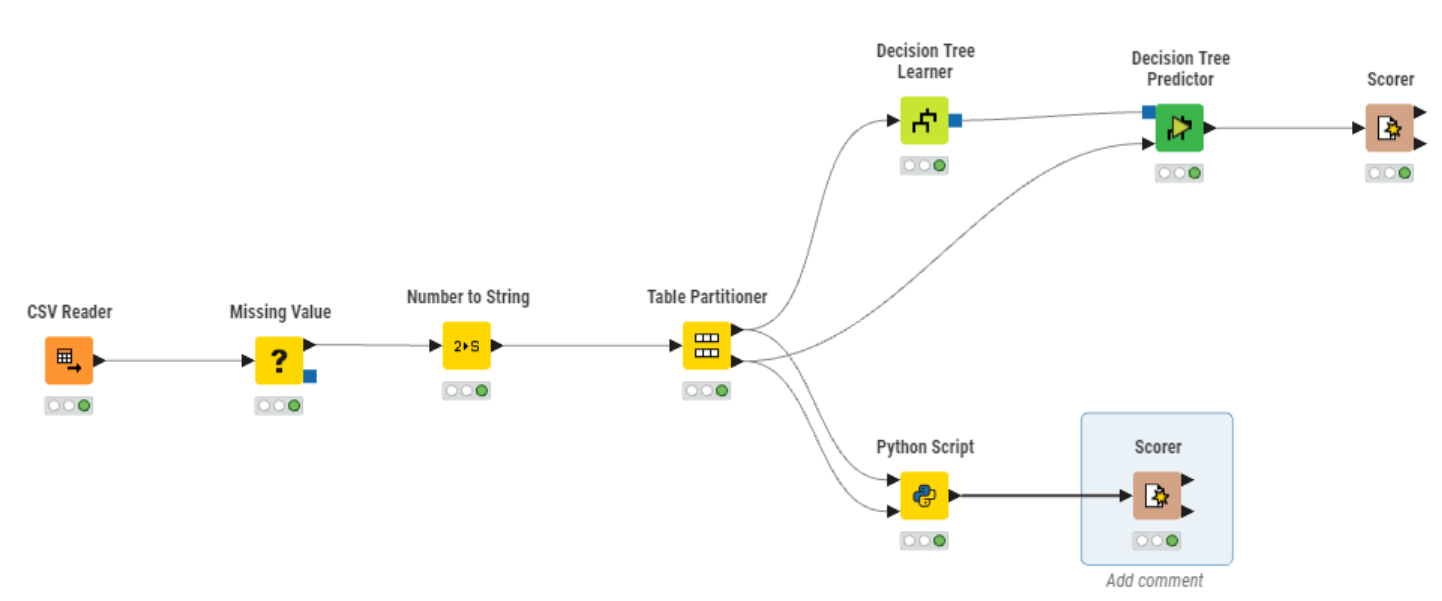


### 1. CSV Reader
Fungsinya adalah untuk membaca dan memasukkan data dari file eksternal berformat .csv ke dalam sistem KNIME agar bisa diolah lebih lanjut.

### 2. Missing Value
Setelah data masuk, seringkali ditemukan baris yang kosong atau tidak lengkap. Di sinilah node Missing Value bekerja untuk menangani data yang "bolong" tersebut.

Tujuannya untuk mencegah terjadinya error pada saat proses pelatihan model.

- Default

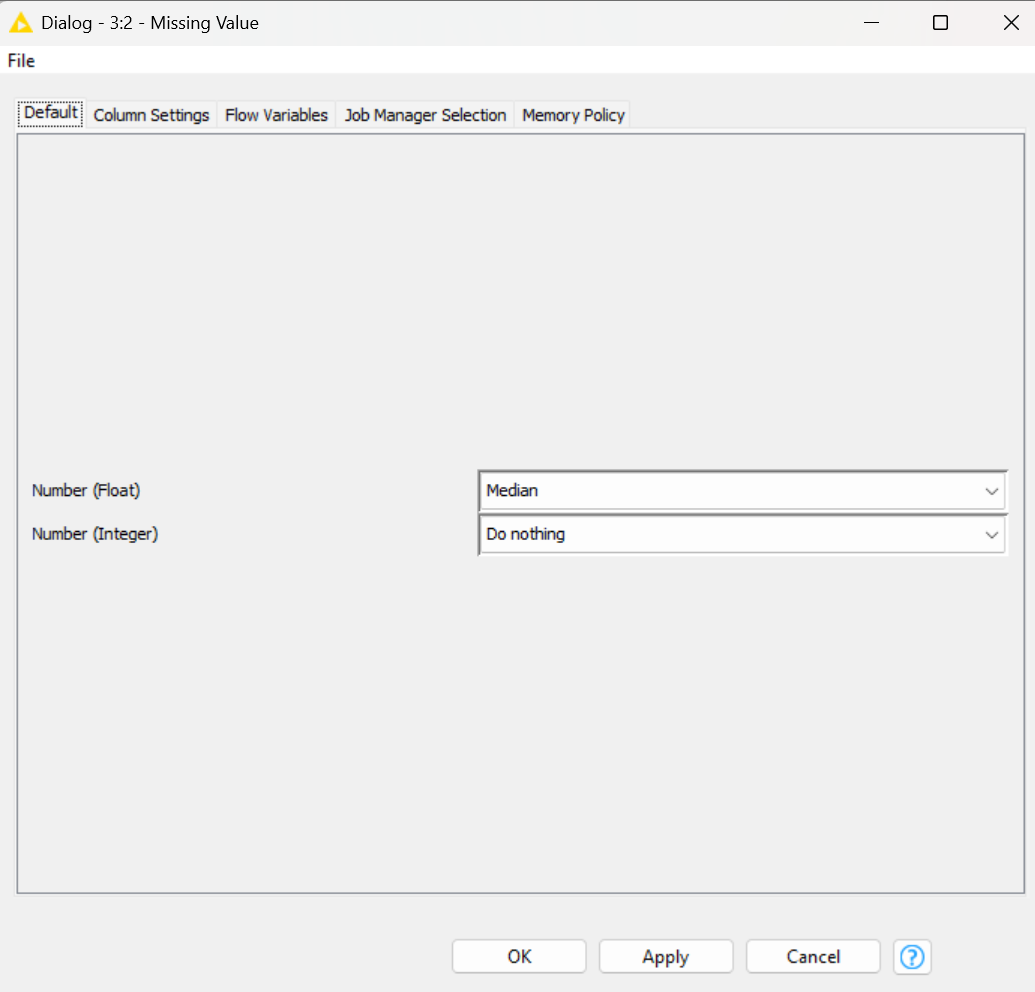

Nilai yang kosong pada kolom angka desimal (Float) diisi menggunakan nilai Median (nilai tengah).

Penggunaan Median dipilih karena lebih stabil dan tidak mudah terpengaruh oleh data ekstrem (outlier) dibandingkan nilai rata-rata.

- Column Setting

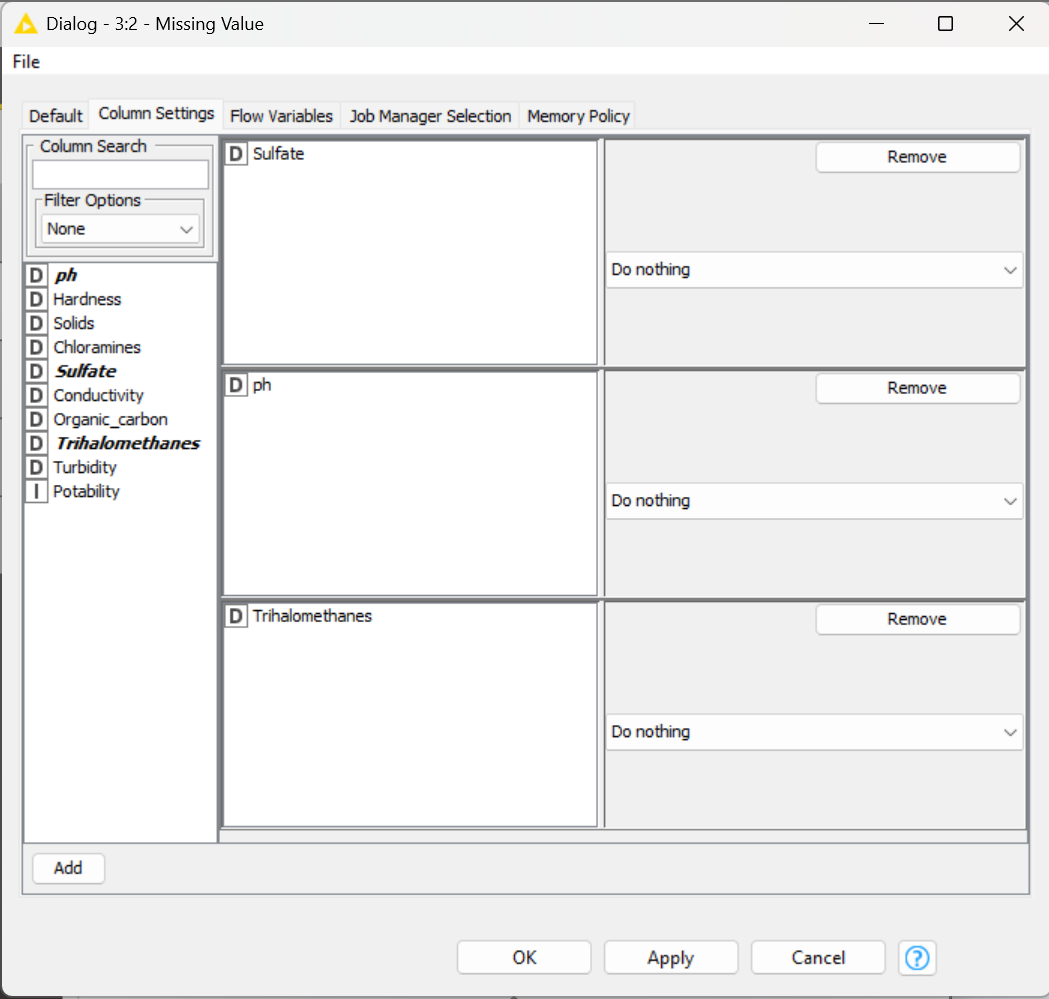

Bagian ini berfungsi untuk mengatur perlakuan berbeda pada kolom tertentu (Sulfate, ph, Trihalomethanes) dibandingkan kolom lainnya.

  -- Tindakan: Memilih opsi "Do Nothing".

  -- Artinya: Nilai kosong pada ketiga kolom tersebut tidak akan diisi atau diubah, melainkan dibiarkan tetap kosong.

  -- Tujuan: Memberikan kontrol manual agar kolom-kolom penting tersebut tidak diproses secara otomatis oleh pengaturan umum (default).




### 3. Number to String
Node ini berfungsi untuk mengubah format data angka menjadi format teks (String).

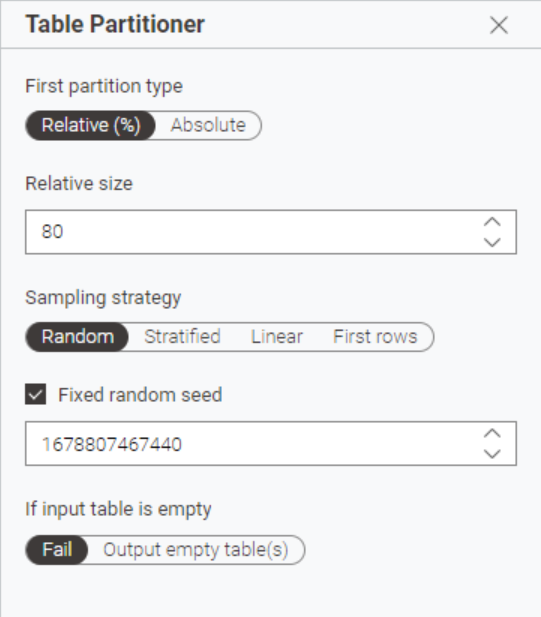

-- Kolom Terpilih: Kolom Potability dipindahkan ke bagian Includes.

-- Tujuan: Mengubah angka 0 dan 1 menjadi label kategori (teks). Hal ini wajib dilakukan agar algoritma klasifikasi mengenali kolom tersebut sebagai Target/Label, bukan sebagai variabel numerik yang akan dihitung nilai matematikanya.


### 4. Table Partitioner
Node ini berfungsi untuk membagi satu dataset menjadi dua bagian terpisah guna keperluan pelatihan dan pengujian model.

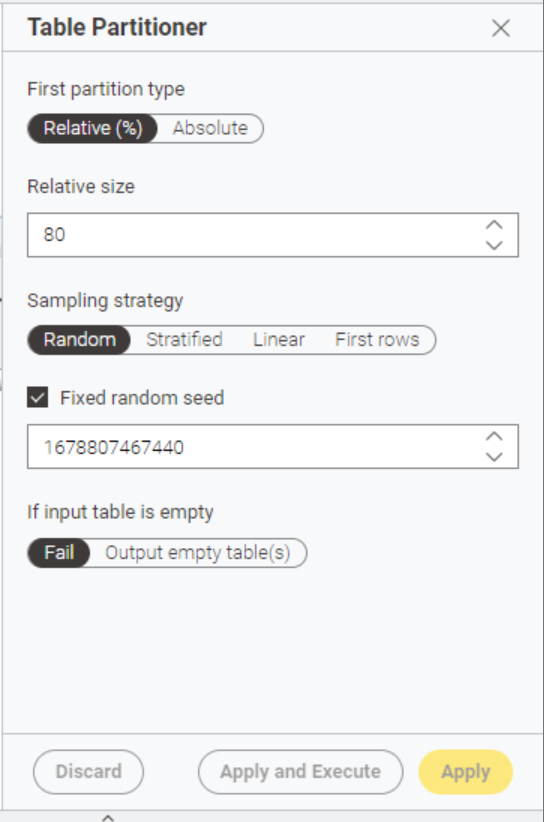

-- Partitioning (80%): Dataset dibagi secara proporsional. Sebanyak 80% data dialokasikan untuk Data Training (pembelajaran model) dan 20% sisanya untuk Data Testing (evaluasi model).

-- Sampling Strategy (Random): Pengambilan data dilakukan secara acak menggunakan metode Random Sampling agar pembagian data bersifat adil dan tidak bias.

-- Fixed Random Seed: Penggunaan angka seed yang tetap bertujuan agar hasil pembagian data tetap konsisten (sama) setiap kali workflow dijalankan ulang.

-- Tujuan: Memastikan model diuji dengan data yang belum pernah dilihat sebelumnya (Testing Data), sehingga akurasi yang dihasilkan benar-benar objektif.

### 5. Decision Tree Learner
Node ini adalah tempat di mana model "belajar" dari data historis. Di sini, algoritma membangun sebuah pohon keputusan (logic tree) untuk memahami pola data air yang layak minum dan tidak.

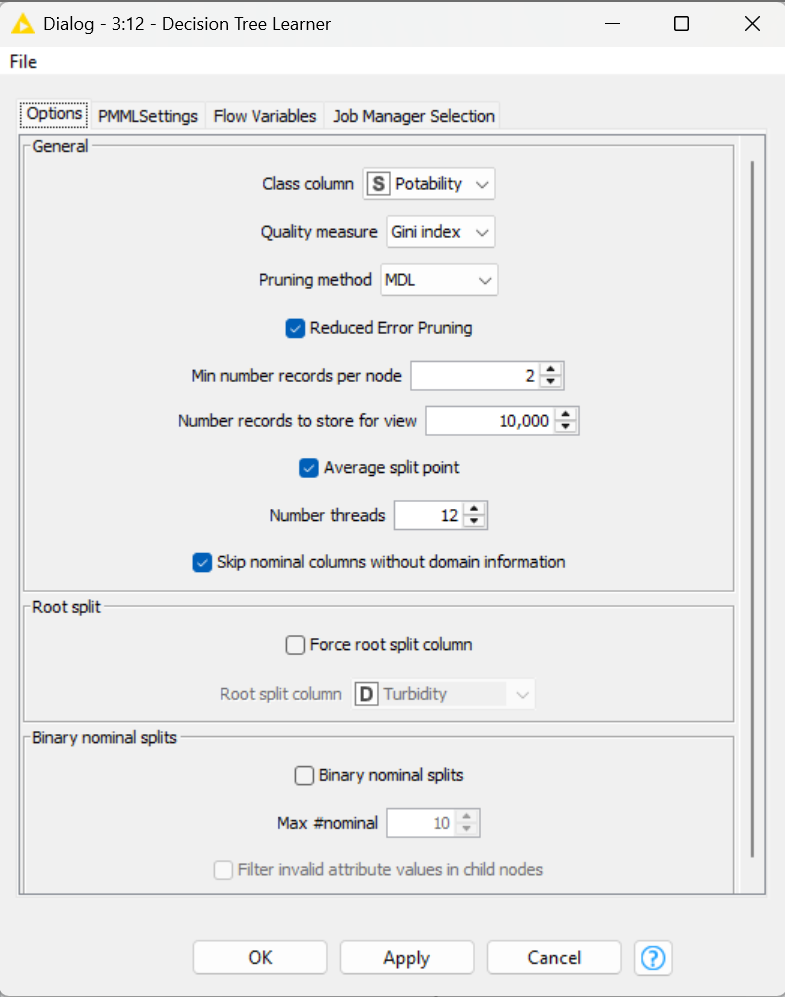

-- Class Column (Potability): Menentukan target yang ingin diprediksi.

-- Quality Measure (Gini Index): Metode statistik yang digunakan pohon untuk menentukan variabel mana (seperti pH atau Sulfate) yang paling kuat dalam memisahkan data secara akurat.

-- Pruning (MDL): Teknik "pemangkasan" cabang pohon yang tidak penting agar model tidak terlalu rumit (overfitting), sehingga lebih cerdas saat menebak data baru.

- Hasil

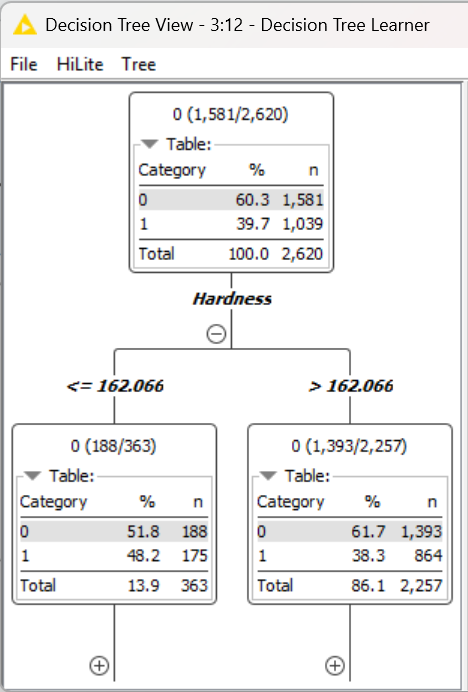

Bagian ini menampilkan logika berpikir model dalam melakukan klasifikasi. Melalui visualisasi ini, kita dapat memahami bagaimana sistem membedakan antara air yang layak minum dan tidak layak minum.

  -- Aturan Utama (Root Node): Model menetapkan bahwa Hardness adalah variabel paling krusial dalam memulai klasifikasi. Pada tahap awal ini, terdapat total 2.620 data dengan distribusi 60,3% (1.581 data) kategori tidak layak (0) dan 39,7% (1.039 data) kategori layak (1).

  -- Pemisahan Berdasarkan Nilai: Algoritma memecah data menjadi dua jalur menggunakan ambang batas nilai 162,066:

      a. Cabang Kiri: Berisi data dengan nilai Hardness ≤ 162,066. Di jalur ini, persentase kategori layak (1) naik menjadi 48,2% dari total 363 data.

      b. Cabang Kanan: Berisi data dengan nilai Hardness > 162,066. Jalur ini didominasi oleh kategori tidak layak (0) sebesar 61,7% dari total 2.257 data.

  -- Interpretasi:Struktur ini membuktikan bahwa klasifikasi dilakukan melalui serangkaian pengujian nilai fitur yang terukur. Dengan melihat pola ini, kita bisa mengetahui bahwa tinggi rendahnya tingkat kekerasan (Hardness) air menjadi indikator awal yang sangat menentukan hasil prediksi.

### 6. Decision Tree Predictor
Setelah model selesai belajar di node Learner, node Predictor bertugas menerapkan ilmu tersebut pada data uji (20% data yang disisihkan tadi).

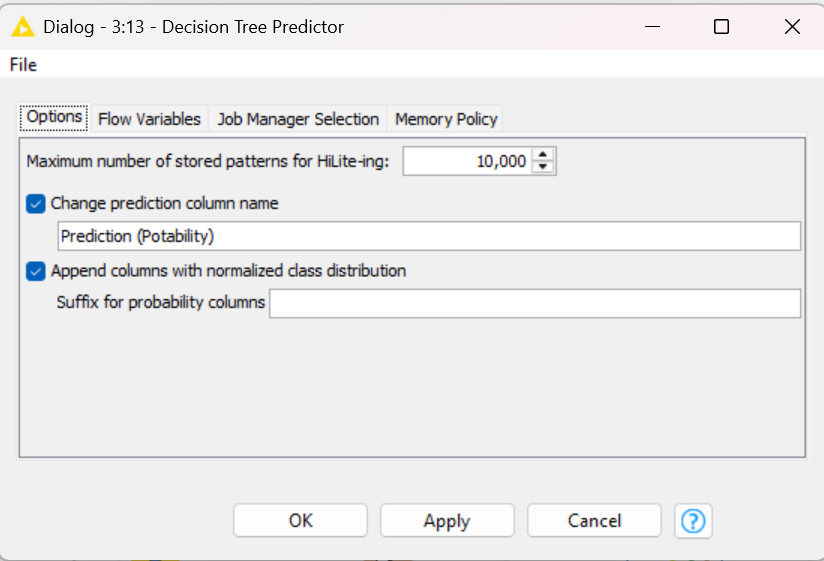

-- Change prediction column name: Fitur ini diaktifkan untuk memberi nama kolom baru hasil prediksi menjadi Prediction (Potability). Hal ini dilakukan agar hasil tebakan model mudah dibedakan dengan data asli.

-- Append columns with normalized class distribution: Opsi ini digunakan untuk menampilkan nilai probabilitas atau tingkat keyakinan model terhadap setiap hasil prediksi yang dikeluarkan.

-- Tujuan: Menghasilkan tabel keluaran yang memuat perbandingan antara data asli dengan hasil prediksi model. Hasil dari node ini nantinya akan menjadi input utama bagi node Scorer untuk menghitung tingkat akurasi model.

- Hasil

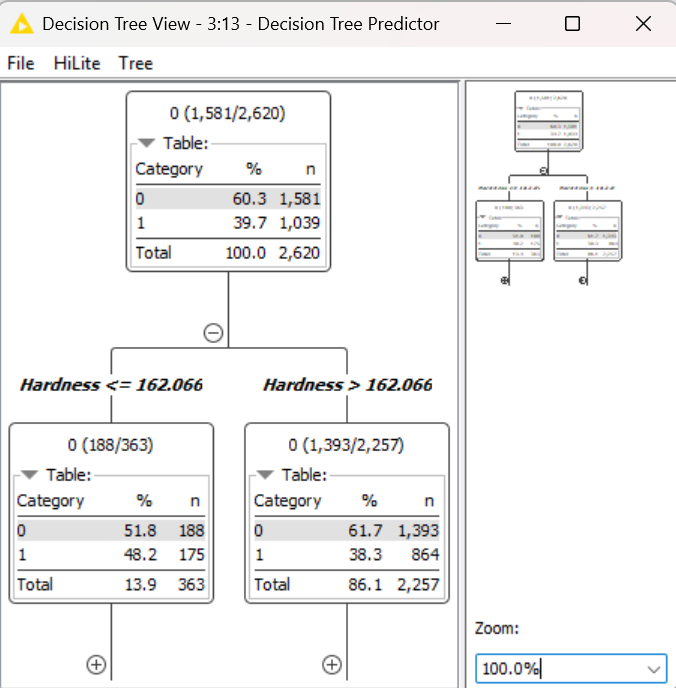

Ini menunjukkan struktur logika yang digunakan model untuk memprediksi data uji. Melalui visualisasi ini, kita dapat memvalidasi aturan klasifikasi yang diterapkan oleh sistem.

-- Distribusi Data pada Root Node: Proses dimulai dengan total 2.620 data, di mana mayoritas data (60,3%) berada pada kategori 0 (tidak layak minum) dan sisanya (39,7%) pada kategori 1 (layak minum).

-- Aturan Pemisahan (Hardness): Model menggunakan variabel Hardness sebagai indikator utama untuk memisahkan data:

    - Jalur Kiri: Untuk data dengan nilai Hardness kurang dari atau sama dengan 162,066. Pada kelompok ini, peluang air layak minum (kategori 1) terlihat lebih besar dibandingkan pada jalur kanan, yaitu mencapai 48,2%.

    - Jalur Kanan: Untuk data dengan nilai Hardness lebih besar dari 162,066. Kelompok ini didominasi oleh kategori tidak layak (0) sebesar 61,7%.

-- Kesimpulan Visual: Pohon ini membagi data secara hierarkis untuk mencapai klasifikasi yang paling akurat. Dengan mengikuti alur dari atas ke bawah, kita bisa memahami alasan teknis mengapa suatu data air diprediksi masuk ke kategori tertentu.

### 7. Scorer
Node Scorer merupakan tahap akhir untuk mengukur sejauh mana performa model dalam melakukan klasifikasi. Node ini membandingkan jawaban asli dengan hasil tebakan yang dibuat oleh model.

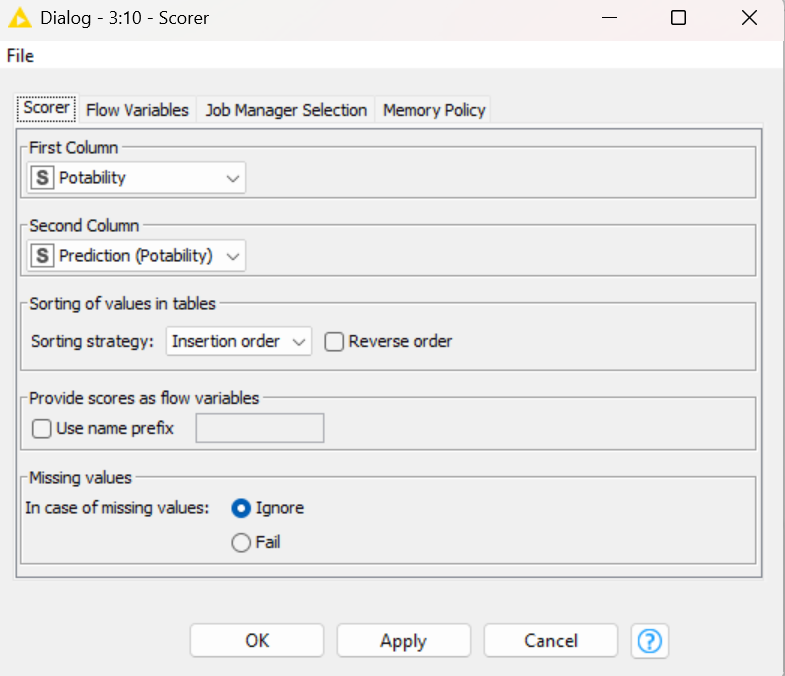

-- First Column (Potability): Kolom ini berisi data aktual atau label asli dari dataset.

-- Second Column (Prediction (Potability)): Kolom ini berisi hasil prediksi yang dikeluarkan oleh algoritma Decision Tree.

-- Mekanisme Kerja: Sistem menghitung kecocokan antara nilai pada kolom pertama dan kedua. Dari perbandingan ini, akan dihasilkan metrik statistik seperti tingkat akurasi (Accuracy), Precision, Recall, dan F-Measure.

-- Tujuan: Memberikan penilaian objektif terhadap kualitas model. Dengan hasil dari node ini, kita dapat menyimpulkan apakah model tersebut sudah cukup handal atau masih memerlukan optimasi lebih lanjut.

- Hasil

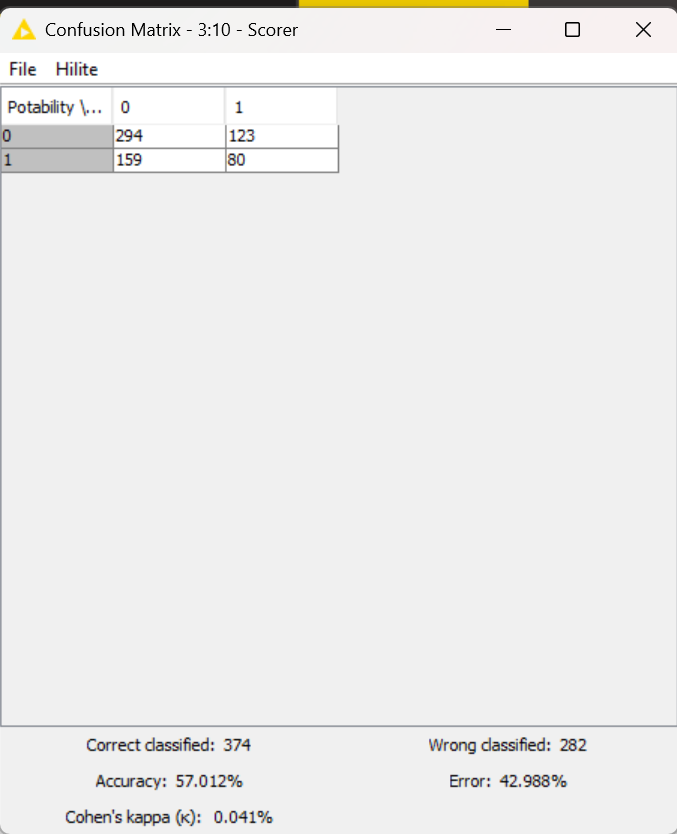

Tampilan ini merinci performa prediksi model secara langsung antara nilai aktual dan hasil prediksi:

-- Correct Classified (374): Model berhasil menebak dengan benar sebanyak 374 data. Terdiri dari 294 data kelas 0 dan 80 data kelas 1 yang sesuai dengan aslinya.

-- Wrong Classified (282): Model salah menebak sebanyak 282 data. Kesalahan ini mencakup data yang seharusnya kelas 0 tapi ditebak 1, serta sebaliknya.

-- Akurasi (57,012%): Dari total keseluruhan data uji, tingkat ketepatan model berada di angka 57%.

-- Kesimpulan: Model cenderung lebih akurat dalam mengenali data pada kategori 0 (294 prediksi benar) dibandingkan kategori 1 (hanya 80 prediksi benar). Hal ini menunjukkan adanya kecenderungan model untuk lebih mengenali pola air yang tidak layak minum.



### 8. Python Script
Node ini digunakan untuk menjalankan skrip Python kustom yang menerapkan algoritma Random Forest Classifier.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import knime.scripting.io as knio

# 1. Ambil data (pakai knio.input_tables)
train_df = knio.input_tables[0].to_pandas()
test_df = knio.input_tables[1].to_pandas()

# 2. Siapkan Fitur dan Target
X_train = train_df.drop(columns=['Potability'])
y_train = train_df['Potability']
X_test = test_df.drop(columns=['Potability'])
y_test = test_df['Potability']

# 3. Model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Prediksi
predictions = model.predict(X_test)

# 5. Output
output_df = test_df.copy()
output_df['Prediction (Potability)'] = predictions
knio.output_tables[0] = knio.Table.from_pandas(output_df)

-- Integrasi Data: Menggunakan pustaka knio untuk mengolah data training dan testing dalam format DataFrame Pandas.

-- Logika Model: Menerapkan Random Forest Classifier dengan 100 pohon keputusan (n_estimators=100). Algoritma ini bekerja dengan menggabungkan hasil dari banyak pohon untuk meningkatkan stabilitas dan akurasi prediksi.

-- Proses Kerja: Skrip memisahkan kolom Potability sebagai target, melatih model pada data train, dan melakukan prediksi pada data test.

-- Output: Hasil prediksi ditambahkan ke tabel sebagai kolom baru bernama Prediction (Potability) untuk dievaluasi lebih lanjut.



### 9. Scorer
Tabel ini merinci efektivitas prediksi model dengan membandingkan nilai aktual dan hasil prediksi:

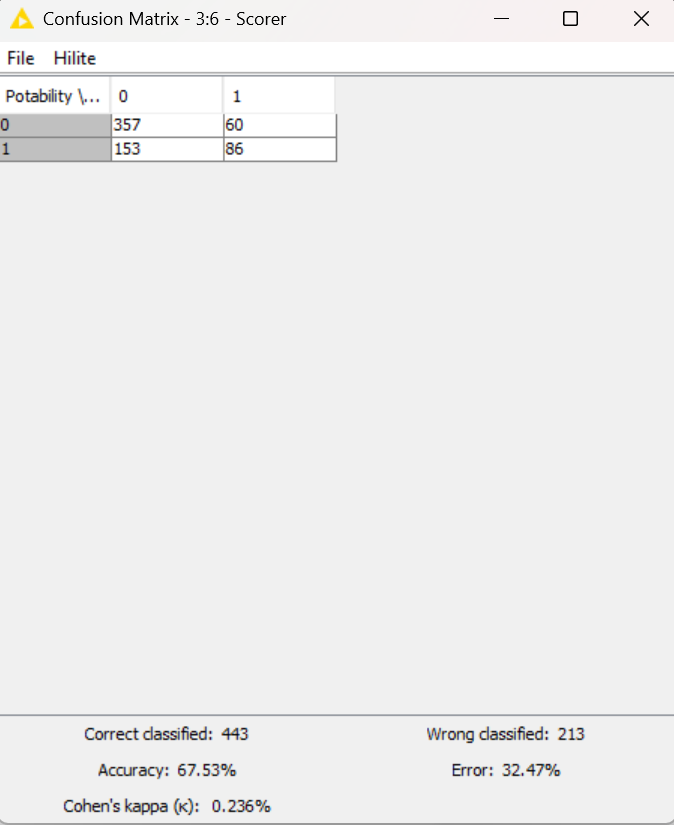

-- Correct Classified (443): Model berhasil memprediksi dengan benar sebanyak 443 data (gabungan 357 data kelas 0 dan 86 data kelas 1).

-- Wrong Classified (213): Model melakukan kesalahan prediksi pada 213 data.

-- Akurasi (67,53%): Tingkat ketepatan model secara keseluruhan mencapai 67,53%. Nilai ini menunjukkan peningkatan performa yang cukup signifikan dibandingkan model sebelumnya.

-- Kesimpulan: Penggunaan Random Forest terbukti lebih efektif dengan peningkatan akurasi sekitar 10%. Model tetap menunjukkan performa yang lebih dominan dalam mendeteksi kategori 0 (357 benar), namun hasil klasifikasi secara total menjadi jauh lebih stabil.

### Kesimpulan

1. Hasil Model Decision Tree

   - Struktur Model: Model ini bekerja seperti diagram alur yang bercabang, di mana setiap keputusan dibuat berdasarkan urutan aturan yang jelas dan mudah dipetakan.

   - Titik Keputusan: Variabel Hardness menjadi penentu paling krusial. Jika nilai Hardness berada pada angka  $\le$  162.066, model akan mengarahkan data tersebut ke kelompok tertentu sesuai pola yang ditemukan.

   - Performa: Akurasi yang didapat adalah 57%. Model ini cukup efektif membaca pola air yang tidak layak, namun masih sering keliru saat menentukan air yang benar-benar layak minum.

2. Hasil Model Random Forest

   - Sistem Kolektif: Berbeda dengan Decision Tree yang hanya mengandalkan satu jalur keputusan, model ini menggunakan 100 pohon keputusan yang bekerja bersama-sama untuk menentukan hasil akhir melalui sistem pemungutan suara terbanyak.

   - Ketangguhan Model: Karena menggabungkan hasil dari banyak pohon, model ini jauh lebih kuat dalam menghadapi variasi data yang acak, sehingga kesalahan pada satu pohon bisa dikoreksi oleh pohon lainnya.

   - Performa: Model ini menunjukkan hasil yang jauh lebih optimal dengan akurasi mencapai 67,53%. Ada peningkatan ketepatan sebesar 10% dibandingkan hanya menggunakan satu pohon tunggal.


**Perbandingan Hasil Performa Model**

| Metrik Evaluasi | Decision Tree | Random Forest |
| :--- | :--- | :--- |
| **Akurasi Keseluruhan** | 57,01% | 67,53% |
| | | |
| **Prediksi Benar** | 374 data | 443 data |
| | | |
| **Kelebihan** | Alur keputusan sangat transparan dan mudah dibaca secara visual. | Lebih stabil dan mampu menangani data yang sulit atau beragam. |
| | | |
| **Kekurangan** | Hasil prediksi kurang akurat untuk dataset yang kompleks. | Pengaturan model lebih rumit karena melibatkan banyak pohon. |



**Kesimpulan Utama:**

Secara keseluruhan, Random Forest merupakan model yang paling tepat untuk digunakan pada dataset ini karena mampu memberikan hasil prediksi yang lebih valid dan stabil dengan peningkatan akurasi sekitar 10% dibandingkan Decision Tree.
  